### LangGraph (랭그래프)

**LangGraph**는 복잡하고 오래 실행되며(long-running) 상태를 유지하는(stateful) AI 에이전트를 구축, 관리, 배포하기 위한 **로우 레벨 오케스트레이션(조율) 프레임워크**입니다.
단순한 프롬프트 체인을 넘어, 지속성(Persistence), 사람의 개입(Human-in-the-loop), 포괄적인 기억력(Memory) 등의 강력한 기반 기능을 제공하여 에이전트가 스스로 판단하고 복잡한 워크플로우를 처리하도록 돕습니다.

이러한 에이전트의 동작은 컴퓨터 과학의 **'그래프(Graph)' 자료구조** 모델을 차용하여, **상태(State)**, **노드(Node)**, **엣지(Edge)** 3가지 핵심 요소로 나누어 정의합니다.

#### 📍 자료구조로서의 그래프 (Graph) 개념도
컴퓨터 과학에서 그래프는 여러 개의 점(Node)들이 선(Edge)으로 연결된 구조를 말합니다. LangGraph도 이와 똑같은 구조로 AI의 작업 흐름을 만듭니다. (필요에 따라 양방향으로 서로 오가며 상호작용할 수 있습니다.)

```mermaid
graph LR
    %% 스타일 정의
    classDef node fill:#e1f5fe,stroke:#4fc3f7,stroke-width:2px,color:#000;
    
    %% 심플한 양방향 그래프 구조 (자료구조)
    A((노드 A)):::node <-->|엣지| B((노드 B)):::node
    A <-->|엣지| C((노드 C)):::node
    B <-->|엣지| D((노드 D)):::node
    C <-->|엣지| D((노드 D)):::node
```

#### 1. State (상태: 공유 수첩 및 기억력)
* **데이터 저장소:** 모든 작업(노드) 과정에서 함께 돌려보고 내용을 덧붙이는 **공통 수첩** 역할을 합니다.
* **기록 내용:** 지금까지 나눈 대화 내역, 검색 결과 등 에이전트의 '현재 상황'을 모두 모아둡니다. 단기 기억뿐만 아니라 세션 간 유지되는 장기 기억도 지원합니다. (주로 `TypedDict` 등 사용)
* **흐름:** 한 작업이 끝나면 수첩(State) 내용이 업데이트되고, 이 수첩이 다음 작업으로 전달됩니다.

#### 2. Node (노드: 실제 행동/작업)
* **실행 단위:** 그래프의 **점**에 해당하며, 실제로 어떤 행동을 수행하는 **각각의 작업 단계**를 말합니다.
* **역할:** 전달받은 수첩(State)을 읽고 필요한 일을 한 뒤, 결과를 수첩에 다시 적습니다.
* **종류:**
    * **LLM 노드:** AI(언어 모델)에게 질문하고 답변을 생성합니다.
    * **도구 노드:** 인터넷 검색이나 API 호출 등 외부 도구를 사용합니다.
    * **함수 노드:** 데이터를 가공하거나 특정 로직을 처리하는 파이썬 함수입니다.

#### 3. Edge (엣지: 진행 방향/길잡이)
* **흐름 제어:** 노드(점)들을 연결해 주는 **선**에 해당하며, 작업들이 어떤 순서로 실행될지 연결해 주는 **길**입니다. 
* **종류:**
    * **일반 엣지:** A 작업이 끝나면 '무조건' B 작업으로 넘어가도록 정해진 길입니다.
    * **조건부 엣지:** 결과나 조건에 따라 갈림길에서 '상황에 맞는' 다음 길을 선택합니다.
* **순환(Loop) 기능:** 양방향 엣지가 보여주듯, 계속 앞만 보고 가는 것이 아니라 필요 시 실패를 복구하거나 **이전 작업으로 다시 돌아가는 구조**를 쉽게 만들 수 있습니다.

In [1]:
from typing import TypedDict

# 1. State 정의
class State(TypedDict):
    message: str

In [2]:
# 2. Node 정의
def greet(state: State):
    greet_message = f"안녕하세요, {state['message']}님!"
    print("greet_message:", greet_message)
    return {"message": greet_message}

In [3]:
# uv add langgraph
from langgraph.graph import StateGraph, START, END

# 3. Graph 생성
graph_builder = StateGraph(State)

# 4. Graph에 Node 추가
graph_builder.add_node("greet_node", greet)

# 5. Edge 추가하여 Node 연결
graph_builder.add_edge(START, "greet_node")
graph_builder.add_edge("greet_node", END)

# 6. Graph를 실행 가능한 형태로 컴파일
graph = graph_builder.compile()

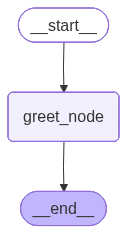

In [5]:
graph

In [6]:
# 7. Graph 실행
initial_message = {"message": "김일남"}
result = graph.invoke(initial_message)
print(f"최종 결과: {result}")

greet_message: 안녕하세요, 김일남님!
최종 결과: {'message': '안녕하세요, 김일남님!'}
